Задание № 1. Проверка выпуклости множества

Мы заставим компьютер проверить математическое определение выпуклости «на прочность». Мы напишем алгоритм, который берет случайные пары точек внутри фигуры, соединяет их отрезком (через выпуклую комбинацию) и проверяет, не вылетел ли отрезок за пределы фигуры. Мы протестируем алгоритм на двух фигурах: 
1. Круг (математически выпуклое множество).
2. Кольцо (невыпуклое множество — внутри дырка).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def is_convex_set_approximation(inside_check_func, bounds, num_trials=500):
    """
    Приближенная проверка множества на выпуклость.
    inside_check_func: функция, которая принимает (x, y) и возвращает True, если точка внутри.
    bounds: ((x_min, x_max), (y_min, y_max)) для генерации случайных точек.
    """
    (x_min, x_max), (y_min, y_max) = bounds
    valid_points = []
    
    # Шаг 1: Генерируем базу точек, которые гарантированно лежат ВНУТРИ множества
    while len(valid_points) < 100:
        rx = np.random.uniform(x_min, x_max)
        ry = np.random.uniform(y_min, y_max)
        if inside_check_func(rx, ry):
            valid_points.append(np.array([rx, ry]))
            
    # Шаг 2: Проверяем случайные пары точек на выпуклую комбинацию
    for _ in range(num_trials):
        # Случайно выбираем две точки из нашей базы
        idx1, idx2 = np.random.choice(len(valid_points), size=2, replace=False)
        p1 = valid_points[idx1]
        p2 = valid_points[idx2]
        
        # ЗАДАНИЕ ДЛЯ ВАС:
        # Сгенерируйте случайный коэффициент theta от 0 до 1
        theta = np.random.uniform(0, 1)
        
        # Посчитайте промежуточную точку 'p_interp' по формуле выпуклой комбинации:
        p_interp = theta * p1 + (1 - theta) * p2
        
        
        # Проверяем, лежит ли точка внутри множества
        if not inside_check_func(p_interp[0], p_interp[1]):
            return False # Нашли контрпример! Множество НЕвыпуклое.
            
    return True # Ни одного нарушения не нашли — множество выпуклое.

# --- ФУНКЦИИ-ФИГУРЫ ДЛЯ ТЕСТИРОВАНИЯ ---

# 1. Круг радиуса 2 (Выпуклый)
def in_circle(x, y):
    return (x**2 + y**2) <= 4

# 2. Кольцо с внешней границей 2 и внутренней 1 (Невыпуклое)
def in_ring(x, y):
    dist_sq = x**2 + y**2
    return (dist_sq >= 1) and (dist_sq <= 4)

# Границы генерации точек от -2.5 до 2.5 по обеим осям
my_bounds = ((-2.5, 2.5), (-2.5, 2.5))

# --- ПРОВЕРКА ---
print("Круг выпуклый?", is_convex_set_approximation(in_circle, my_bounds))
print("Кольцо выпуклое?", is_convex_set_approximation(in_ring, my_bounds))


Круг выпуклый? True
Кольцо выпуклое? False


Задание №2: Выпуклая оболочка (Convex Hull).

В этом задании мы визуализируем то, как алгоритм QuickHull «окутывает» облако случайных точек жесткой выпуклой границей (как будто мы натянули канцелярскую резинку вокруг вбитых в доску гвоздей).

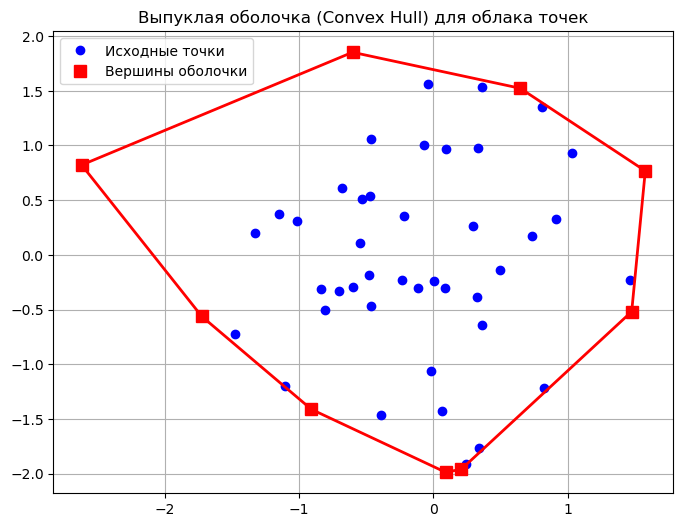

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

# 1. Генерируем 50 случайных точек на плоскости (нормальное распределение)
np.random.seed(42)  # Фиксируем сид для воспроизводимости
points = np.random.randn(50, 2)

# 2. Строим выпуклую оболочку
hull = ConvexHull(points)

# 3. Визуализируем результат
plt.figure(figsize=(8, 6))

# Рисуем все исходные точки синими кружками
plt.plot(points[:, 0], points[:, 1], 'o', color='blue', label='Исходные точки')

# Проходимся по вершинам оболочки и соединяем их красной линией
# hull.simplices содержит индексы точек, образующих грани (отрезки) оболочки
for simplex in hull.simplices:
    plt.plot(points[simplex, 0], points[simplex, 1], 'r-', linewidth=2)

# Дополнительно выделим сами вершины оболочки красными квадратами
plt.plot(points[hull.vertices, 0], points[hull.vertices, 1], 'rs', markersize=8, label='Вершины оболочки')

plt.title('Выпуклая оболочка (Convex Hull) для облака точек')
plt.legend()
plt.grid(True)
plt.show()


Заданию №3: Сумма Минковского (Minkowski Sum).

На лекции говорилось, что сумма Минковского двух множеств \(A\) и \(B\) — это попарная сумма каждого вектора из \(A\) с каждым вектором из \(B\). Давайте наглядно увидим, как «сложение» треугольника и квадрата порождает новую сложную фигуру.

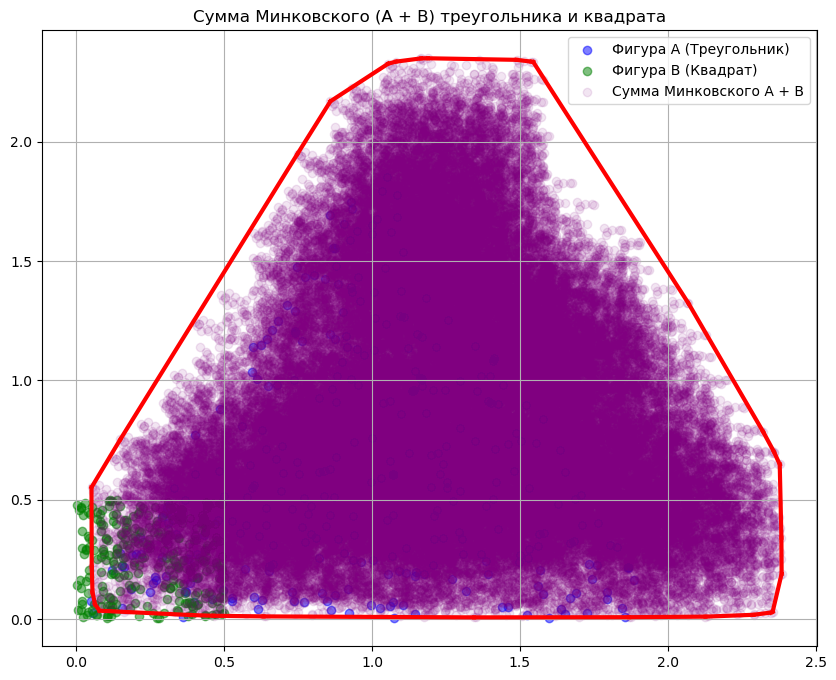

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull

# 1. Генерируем точки ВНУТРИ исходных фигур с помощью случайных весов
np.random.seed(42)
n_samples = 300

# Фигура A: Треугольник с вершинами (0,0), (2,0), (1,2)
# (генерируем точки через выпуклую комбинацию вершин)
v_A = np.array([[0, 0], [2, 0], [1, 2]])
w_A = np.random.dirichlet(np.ones(3), size=n_samples)
points_A = w_A @ v_A

# Фигура B: Маленький квадрат с вершинами (0,0), (0,0.5), (0.5,0.5), (0.5,0)
points_B = np.random.uniform(0, 0.5, size=(n_samples, 2))

# 2. ЗАДАНИЕ ДЛЯ ВАС: Посчитайте сумму Минковского.
# Вам нужно сложить каждую точку из points_A с каждой точкой из points_B.
# Подсказка: Проще всего сделать это через два вложенных цикла по n_samples 
# и сохранить результат в список, который потом превратить в np.array.

minkowski_points = []

# НАПИШИТЕ ВАШ ЦИКЛ ТУТ:
for i in points_A:
    for j in points_B:
        minkowski_points.append(i + j)

minkowski_points = np.array(minkowski_points)

# 3. Находим выпуклую оболочку для суммы Минковского
hull_m = ConvexHull(minkowski_points)

# 4. Визуализация
plt.figure(figsize=(10, 8))
plt.scatter(points_A[:, 0], points_A[:, 1], color='blue', alpha=0.5, label='Фигура A (Треугольник)')
plt.scatter(points_B[:, 0], points_B[:, 1], color='green', alpha=0.5, label='Фигура B (Квадрат)')
plt.scatter(minkowski_points[:, 0], minkowski_points[:, 1], color='purple', alpha=0.1, label='Сумма Минковского A + B')

# Рисуем контур суммы Минковского
for simplex in hull_m.simplices:
    plt.plot(minkowski_points[simplex, 0], minkowski_points[simplex, 1], 'r-', linewidth=3)

plt.title('Сумма Минковского (A + B) треугольника и квадрата')
plt.legend()
plt.grid(True)
plt.show()


Задание №4: Конусы и Коническая комбинация.

Мы помним, что коническая комбинация двух векторов v1 и v2 — это l1v1 + l2v2, где оба коэффициента l >= 0. Она создает бесконечный «раструб» на плоскости.

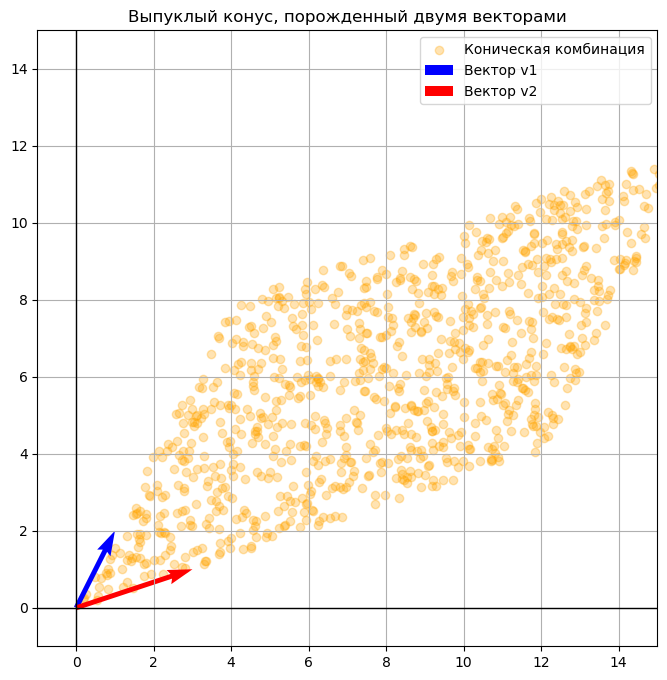

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Задаем два базовых вектора (луча)
v1 = np.array([1, 2])
v2 = np.array([3, 1])

# 2. Генерируем случайные положительные коэффициенты lambda_1 и lambda_2
np.random.seed(42)
n_points = 1000
l1 = np.random.uniform(0, 4, n_points)
l2 = np.random.uniform(0, 4, n_points)

# 3. Считаем коническую комбинацию по формуле
cone_points = np.zeros((n_points, 2))
for i in range(n_points):
    cone_points[i] = l1[i] * v1 + l2[i] * v2

# 4. Визуализация конуса
plt.figure(figsize=(8, 8))

# Рисуем получившиеся точки конической оболочки
plt.scatter(cone_points[:, 0], cone_points[:, 1], color='orange', alpha=0.3, label='Коническая комбинация')

# Выделяем исходные направляющие векторы жирными стрелками из нуля
plt.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1, color='blue', width=0.008, label='Вектор v1')
plt.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.008, label='Вектор v2')

# Настройка осей
plt.xlim(-1, 15)
plt.ylim(-1, 15)
plt.axhline(0, color='black',linewidth=1)
plt.axvline(0, color='black',linewidth=1)
plt.title('Выпуклый конус, порожденный двумя векторами')
plt.legend()
plt.grid(True)
plt.show()


Заданию №5: Выпуклые функции (Неравенство Йенсена).

На лекции обсуждалось ключевое свойство выпуклой функции: хорда, соединяющая любые две точки графика, всегда лежит выше или на уровне самого графика функции. 

In [8]:
import numpy as np

def check_convexity(func, x_range=(-2, 2), num_trials=1000):
    for _ in range(num_trials):
        x1 = np.random.uniform(*x_range)
        x2 = np.random.uniform(*x_range)
        theta = np.random.uniform(0, 1)
        
        # Левая часть неравенства Йенсена
        f_interp = func(theta * x1 + (1 - theta) * x2)
        # Правая часть неравенства Йенсена
        chord_interp = theta * func(x1) + (1 - theta) * func(x2)
        
        # Если график оказался выше хорды (с учетом погрешности) — функция НЕвыпуклая
        if f_interp > chord_interp + 1e-9:
            return False
    return True

# Тестируем две функции
f_convex = lambda x: x**2
f_non_convex = lambda x: x**3

print("Функция f(x) = x^2 выпуклая?", check_convexity(f_convex))
print("Функция f(x) = x^3 выпуклая на (-2, 2)?", check_convexity(f_non_convex))


Функция f(x) = x^2 выпуклая? True
Функция f(x) = x^3 выпуклая на (-2, 2)? False
